In [1]:
import sys
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add dirctory with model moduels to path
sys.path.insert(0, os.path.join(os.getcwd(),'..'))

import CIBUSmod as cm
from CIBUSmod.utils.output_data_manip import concat_herds

# Create input data
x0_crp.csv and x0_ani.csv represent the current areas of different crops and number of heads of different animals respectively. These are both still WIP, which is why some mangling is needed here to get them in the right form.
The demand vector is generated with demand for cattle meat, pig meat and cattle milk equal to what is in the agricultural statistics.

In [2]:
# Define x0_crp
x0_crp = \
    pd.read_csv(os.path.join('..','data','x0','x0_crp.csv'), dtype={'region': object})\
    .set_index(['crop','prod_system','region'])['area']

# Define x0_ani
x0_ani = pd.read_csv(os.path.join('..','data','x0','x0_ani.csv'), dtype={'region': object})

x0_ani['species'] = np.nan
x0_ani['species'] = \
np.where(np.isin(x0_ani['animal'], ['kor för mjölkproduktion', 'kor för uppfödning av kalvar']),'cattle',x0_ani['species'])
x0_ani['species'] = \
np.where(x0_ani['animal']=='suggor för avel','pigs',x0_ani['species'])

x0_ani['breed'] = np.nan
x0_ani['breed'] = \
np.where(x0_ani['animal']=='kor för mjölkproduktion','dairy',x0_ani['breed'])
x0_ani['breed'] = \
np.where(x0_ani['animal']=='kor för uppfödning av kalvar','beef',x0_ani['breed'])
x0_ani['breed'] = \
np.where(x0_ani['animal']=='suggor för avel','none',x0_ani['breed'])

x0_ani = x0_ani[x0_ani['species']!='nan'][['species','breed','prod_system','region','number']].set_index(['species','breed','prod_system','region'])['number']

x0_ani = x0_ani.fillna(0)

x0 = {'ani':x0_ani,'crp':x0_crp}

In [3]:
# Create demand vectors
D=dict()

In [4]:
# Animal products
D['ani'] = pd.Series(
    {
        ('conventional','cattle','meat') : (136-21) * 1000000,
        ('organic','cattle','meat')      : 21 * 1000000,
        ('conventional','cattle','milk') : (2760-464) * 1000000,
        ('organic','cattle','milk')      : 464 * 1000000,
        ('conventional','pigs','meat')   : (249-6) * 1000000,
        ('organic','pigs','meat')        : 6 * 1000000,
    },
)
D['ani'].index.rename(['prod_system','species','animal_prod'], inplace=True)

In [5]:
# Crop products (kg DM)
D['crp'] = pd.Series(
    {
        ('conventional','wheat')         :0,
        ('organic','wheat')              :0,
    },
)
D['crp'].index.rename(['prod_system','crop_prod'], inplace=True)

## Work on Diet class

In [6]:
# Instantiate diet class
diet = cm.Diet(
    par = cm.ParameterRetriever(
        os.path.join('..','data','prod_parameters','Diet.xlsx')
    )
)

In [7]:
# Calculate food demand
diet.calculate(verbose=True)

[10:42:41][Diet] Calculating food demand ...
[10:42:41][Diet] Calculating waste ...
[10:42:41][Diet] Calculating crop product demand ...
[10:42:41][Diet] Calculating crop product demand ...
[10:42:42][Diet] Done! Elapsed time: 0 sec


In [ ]:
##################################################
##################################################

In [ ]:
round(diet.crop_prod_demand/1000000,1) # 1000 ton

In [ ]:
round(diet.crop_by_products/1000000,1) # 1000 ton

In [ ]:
round(diet.animal_prod_demand/1000000,1) # 1000 ton

In [ ]:
round(diet.animal_by_products/1000000,1) # 1000 ton

In [ ]:
round(diet.induced_skim_milk_exports/1000000,1)*0.1 # 1000 ton powder

In [8]:
D['crp'] = diet.crop_prod_demand

In [9]:
D['ani'] = diet.animal_prod_demand

In [ ]:
######################################################
######################################################

# Run base year
This runs the model for the base year (2016-2020). Results are then compared to statistics to ensure feasible results replicating the current situation.

In [10]:
# Instantiate crop production
crops = cm.CropProduction(
    par = cm.ParameterRetriever(
        os.path.join('..','data','prod_parameters','CropProduction.xlsx')
    ),
    index = x0_crp.index
)    

# Instantiate animal herds
herds=pd.Series(
    data=[],
    index=pd.MultiIndex(
        levels=[[]]*4,
        codes=[[]]*4,
        names=['species','breed','prod_system','sub_system']
    ),
    dtype = object
)

for (sp,br,ps) in x0_ani.groupby(['species','breed','prod_system']).sum().index:
            
    if sp == 'cattle':
        herds[(sp,br,ps,'none')] = \
            cm.CattleHerd(
                par = cm.ParameterRetriever(
                    os.path.join('..','data','prod_parameters','CattleHerd.xlsx')
                ),
                index = x0_ani.index.get_level_values('region').unique(),
                breed = br,
                prod_system = ps
            )

    elif sp == 'pigs':
        herds[(sp,br,ps,'none')] = \
            cm.PigHerd(
                par = cm.ParameterRetriever(
                    os.path.join('..','data','prod_parameters','PigHerd.xlsx')
                ),
                index = x0_ani.index.get_level_values('region').unique(),
                breed = br,
                prod_system = ps
            ) 

# Instantiate manure management
feed_mgmt = cm.FeedMgmt(
    herds = herds,
    par = cm.ParameterRetriever(
        os.path.join('..','data','prod_parameters','FeedMgmt.xlsx')
    )
)

# Instantiate manure management
manure_mgmt = cm.ManureMgmt(
    herds = herds,
    par = cm.ParameterRetriever(
        os.path.join('..','data','prod_parameters','ManureMgmt.xlsx')
    )
)

# Instantiate geo distributor
geodist = cm.GeoDistributor(D,x0,crops,herds,feed_mgmt)

# -------------------------------------------------------------------- #

# Calculate crops
crops.calculate(
    verbose = True
)

# Calculate herds
for h in herds:
    h.calculate(verbose = True)

# Calculate feed
feed_mgmt.calculate(verbose=True)    

# Calculate manure
# manure_mgmt.calculate(verbose=True)

[10:42:51][CropProduction] Calculating harvest ...
[10:42:51][CropProduction] Calculating production ...
[10:42:52][CropProduction] Done! Elapsed time: 0 sec
[10:42:52][AnimalHerd (cattle, beef, conventional, none)] Calculating herd structure ...
[10:42:52][AnimalHerd (cattle, beef, conventional, none)] Calculating production ...
[10:42:52][AnimalHerd (cattle, beef, conventional, none)] Done! Elapsed time: 0 sec
[10:42:52][AnimalHerd (cattle, beef, organic, none)] Calculating herd structure ...
[10:42:53][AnimalHerd (cattle, beef, organic, none)] Calculating production ...
[10:42:53][AnimalHerd (cattle, beef, organic, none)] Done! Elapsed time: 1 sec
[10:42:53][AnimalHerd (cattle, dairy, conventional, none)] Calculating herd structure ...
[10:42:53][AnimalHerd (cattle, dairy, conventional, none)] Calculating production ...
[10:42:53][AnimalHerd (cattle, dairy, conventional, none)] Done! Elapsed time: 0 sec
[10:42:53][AnimalHerd (cattle, dairy, organic, none)] Calculating herd structure

In [36]:
# Distribute animals and crops
geodist.make(use_cons=[1,2,3,4], scaling='item', verbose=True)

[10:49:53][GeoDist.make] Scaling ...
[10:49:53][GeoDist.make] Making constraint C1 ...
[10:49:57][GeoDist.make] Making constraint C2 ...
[10:50:55][GeoDist.make] Making constraint C3 ...
[10:50:55][GeoDist.make] Making constraint C4 ...
[10:50:55][GeoDist.make] Making objective O1 ...
[10:50:55][GeoDist.make] Defining problem ...
[10:50:55][GeoDist.make] Done! Elapsed time: 62 sec


In [70]:
1e5

100000.0

In [72]:
geodist.problem

Problem(Minimize(Expression(CONVEX, NONNEGATIVE, ())), [Equality(Expression(AFFINE, UNKNOWN, (20,)), Constant(CONSTANT, NONNEGATIVE, (20,))), Inequality(Constant(CONSTANT, ZERO, ())), Inequality(Expression(AFFINE, NONNEGATIVE, (106,))), Inequality(Expression(AFFINE, NONNEGATIVE, (106,)))])

In [212]:
geodist.solve(
    verbose=True,
    solver_settings = {
        'solver':'OSQP',
        'max_iter':100000,
        'eps_abs':1e-6,
        'eps_rel':1e-6,
        'verbose':True
    }
)

[11:54:23][GeoDist.solve] Finding solution ...
                                     CVXPY                                     
                                     v1.3.0                                    
(CVXPY) May 02 11:54:23 AM: Your problem has 12084 variables, 4 constraints, and 0 parameters.
(CVXPY) May 02 11:54:23 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) May 02 11:54:23 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) May 02 11:54:23 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) May 02 11:54:23 AM: Using cached ASA map, for faster compilation (bypassing reduction chain).
(CVXPY) May 

20800   2.4338e+08   2.56e+00   8.42e-03   1.56e-04   1.57e+01s
21000   2.4338e+08   2.56e+00   8.42e-03   1.56e-04   1.59e+01s
21200   2.4338e+08   2.56e+00   8.42e-03   1.56e-04   1.60e+01s
21400   2.4338e+08   2.56e+00   8.42e-03   1.56e-04   1.61e+01s
21600   2.4338e+08   2.56e+00   8.41e-03   1.56e-04   1.63e+01s
21800   2.4338e+08   2.56e+00   8.41e-03   1.56e-04   1.65e+01s
22000   2.4338e+08   2.56e+00   8.41e-03   1.56e-04   1.66e+01s
22200   2.4338e+08   2.55e+00   8.40e-03   1.56e-04   1.68e+01s
22400   2.4338e+08   2.55e+00   8.40e-03   1.56e-04   1.69e+01s
22600   2.4338e+08   2.55e+00   8.40e-03   1.56e-04   1.71e+01s
22800   2.4338e+08   2.55e+00   8.39e-03   1.56e-04   1.73e+01s
23000   2.4338e+08   2.55e+00   8.39e-03   1.56e-04   1.75e+01s
23200   2.4338e+08   2.55e+00   8.39e-03   1.56e-04   1.76e+01s
23400   2.4338e+08   2.55e+00   8.39e-03   1.56e-04   1.78e+01s
23600   2.4338e+08   2.55e+00   8.38e-03   1.56e-04   1.79e+01s
23800   2.4338e+08   2.55e+00   8.38e-03

46800   2.4338e+08   2.45e+00   8.04e-03   1.56e-04   3.52e+01s
47000   2.4338e+08   2.44e+00   8.04e-03   1.56e-04   3.53e+01s
47200   2.4338e+08   2.44e+00   8.04e-03   1.56e-04   3.55e+01s
47400   2.4338e+08   2.44e+00   8.03e-03   1.56e-04   3.56e+01s
47600   2.4338e+08   2.44e+00   8.03e-03   1.56e-04   3.58e+01s
47800   2.4338e+08   2.44e+00   8.03e-03   1.56e-04   3.59e+01s
48000   2.4338e+08   2.44e+00   8.02e-03   1.56e-04   3.61e+01s
48200   2.4338e+08   2.44e+00   8.02e-03   1.56e-04   3.62e+01s
48400   2.4338e+08   2.44e+00   8.02e-03   1.56e-04   3.63e+01s
48600   2.4338e+08   2.44e+00   8.02e-03   1.56e-04   3.65e+01s
48800   2.4338e+08   2.44e+00   8.01e-03   1.56e-04   3.66e+01s
49000   2.4338e+08   2.44e+00   8.01e-03   1.56e-04   3.68e+01s
49200   2.4338e+08   2.44e+00   8.01e-03   1.56e-04   3.69e+01s
49400   2.4338e+08   2.43e+00   8.00e-03   1.56e-04   3.70e+01s
49600   2.4338e+08   2.43e+00   8.00e-03   1.56e-04   3.72e+01s
49800   2.4338e+08   2.43e+00   8.00e-03

72800   2.4338e+08   2.34e+00   7.68e-03   1.56e-04   5.45e+01s
73000   2.4338e+08   2.33e+00   7.67e-03   1.56e-04   5.46e+01s
73200   2.4338e+08   2.33e+00   7.67e-03   1.56e-04   5.48e+01s
73400   2.4338e+08   2.33e+00   7.67e-03   1.56e-04   5.49e+01s
73600   2.4338e+08   2.33e+00   7.67e-03   1.56e-04   5.51e+01s
73800   2.4338e+08   2.33e+00   7.66e-03   1.56e-04   5.52e+01s
74000   2.4338e+08   2.33e+00   7.66e-03   1.56e-04   5.53e+01s
74200   2.4338e+08   2.33e+00   7.66e-03   1.56e-04   5.55e+01s
74400   2.4338e+08   2.33e+00   7.66e-03   1.56e-04   5.56e+01s
74600   2.4338e+08   2.33e+00   7.65e-03   1.56e-04   5.58e+01s
74800   2.4338e+08   2.33e+00   7.65e-03   1.56e-04   5.59e+01s
75000   2.4338e+08   2.33e+00   7.65e-03   1.56e-04   5.60e+01s
75200   2.4338e+08   2.33e+00   7.64e-03   1.56e-04   5.62e+01s
75400   2.4338e+08   2.32e+00   7.64e-03   1.56e-04   5.63e+01s
75600   2.4338e+08   2.32e+00   7.64e-03   1.56e-04   5.65e+01s
75800   2.4338e+08   2.32e+00   7.64e-03

98600   2.4339e+08   2.23e+00   7.33e-03   1.56e-04   7.40e+01s
98800   2.4339e+08   2.23e+00   7.33e-03   1.56e-04   7.41e+01s
99000   2.4339e+08   2.23e+00   7.33e-03   1.56e-04   7.43e+01s
99200   2.4339e+08   2.23e+00   7.32e-03   1.56e-04   7.44e+01s
99400   2.4339e+08   2.23e+00   7.32e-03   1.56e-04   7.45e+01s
99600   2.4339e+08   2.23e+00   7.32e-03   1.56e-04   7.47e+01s
99800   2.4339e+08   2.23e+00   7.32e-03   1.56e-04   7.48e+01s
100000   2.4339e+08   2.23e+00   7.31e-03   1.56e-04   7.50e+01s

status:               solved
number of iterations: 100000
optimal objective:    243385758.9668
run time:             7.50e+01s
optimal rho estimate: 3.06e-04

-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
(CVXPY) May 02 11:55:38 AM: Problem status: optimal
(CVXPY) May 02 11:55:38 AM: Optimal

In [213]:
# Scale and store results
out_crops = crops.scale(geodist.x['crp'])

out_animals = concat_herds([
    h.scale(
        geodist.x['ani'].loc[(h.species,h.breed,h.prod_system,h.sub_system)],
        x_is = h.x_is
    )
    for h in herds
])

# Check solution

### Check constraints

In [214]:
C1_atol = 10 # [kg]
C1_rtol = 0.01/100 # 0.01%

C2_tol = 10 # [kg]

C3_atol = 10 # [ha]
C3_rtol = 0.01/100 # 0.01%

C4_atol = 10 # [ha]
C4_rtol = 0.01/100 # 0.01%

C1_pass = np.isclose(
    geodist.A1.M @ np.concatenate((geodist.xs['ani'].values,geodist.xs['crp'].values)),
    geodist.b1,
    rtol=C1_rtol, atol=C1_atol
)

C2_pass = (
    geodist.A2.M @ np.concatenate((geodist.xs['ani'].values,geodist.xs['crp'].values))
    >= -C2_tol
)

C3_pass = (
    geodist.A3.M @ np.concatenate((geodist.xs['ani'].values,geodist.xs['crp'].values))
    - (C3_atol + geodist.b3*(1+C3_rtol))
    <= 0
)

C4_pass = (
    geodist.A4.M @ np.concatenate((geodist.xs['ani'].values,geodist.xs['crp'].values))
    - (C4_atol + geodist.b4*(1+C4_rtol))
    <= 0
)

if not C1_pass.all():
    print('C1 animals:')
    print(geodist.A1.rows['ani'][~C1_pass[:len(geodist.D['ani'])]])
    
    print('C1 crops:')
    print(geodist.A1.rows['ani'][~C1_pass[:len(geodist.D['ani'])]])
    
if not C2_pass.all():
    print('C2:')
    print(geodist.A2.rows[~C2_pass])
    
if not C3_pass.all():
    print('C3:')
    print(geodist.A3.rows[~C3_pass])
    
if not C4_pass.all():
    print('C4:')
    print(geodist.A4.rows[~C4_pass])

C3:
Index(['2019'], dtype='object', name='region')


In [227]:
# Check constraint C1 (production meets demand)
round(pd.Series(
    geodist.A1.M @ np.concatenate((geodist.xs['ani'].values,geodist.xs['crp'].values)) - geodist.b1,
    index=np.concatenate((geodist.A1.rows['ani'].values,geodist.A1.rows['crp'].values))
)/1000,2)

(conventional, cattle, meat)    0.00
(conventional, cattle, milk)    0.00
(conventional, pigs, meat)     -0.00
(organic, cattle, meat)         0.00
(organic, cattle, milk)         0.00
(organic, pigs, meat)          -0.00
(conventional, wheat)           0.00
(conventional, barley)          0.01
(conventional, rye)             0.00
(conventional, oats)            0.00
(organic, wheat)                0.00
(organic, barley)               0.01
(organic, rye)                  0.00
(organic, oats)                 0.00
(conventional, fodder)          0.00
(organic, fodder)               0.00
(conventional, maize fodder)    0.00
(organic, maize fodder)         0.00
(conventional, grazing)        -0.00
(organic, grazing)             -0.00
dtype: float64

Check output tables that production meets demand

Prod - Diet - Feed = 0

In [228]:
# Check if crop production meets demand
tmp = pd.concat([
    # Crop production
    out_crops.production.rename_axis(columns='crop_prod').stack().groupby(['prod_system','crop_prod']).sum().rename('prod'),
    # Diet demand
    -geodist.D['crp'].rename('diet'),
    # Feed demand
    -out_animals.feed.crop_product_demand
    .xs('domestic',level='origin',axis=1)
    .groupby(['prod_system','crop_prod'],axis=1)
    .sum().sum()
    .rename('feed')
], axis=1)
tmp['sum'] = tmp.sum(axis=1)
round(tmp/1000,1)


prod      diet       feed  sum
prod_system  crop_prod                                        
conventional maize fodder        0.0      -0.0        NaN  0.0
             fodder        1970377.9      -0.0 -1970377.9  0.0
             grazing        692645.7      -0.0  -692645.7 -0.0
             wheat         2255705.4 -501666.2 -1754039.2  0.0
             barley          20236.1  -20236.1        NaN  0.0
             rye             74057.6  -74057.6        NaN  0.0
             oats            47188.7  -47188.7        NaN  0.0
organic      maize fodder        0.0      -0.0        NaN  0.0
             fodder         434947.8      -0.0  -434947.8  0.0
             grazing        171397.2      -0.0  -171397.2 -0.0
             wheat          239263.1  -28076.4  -211186.7  0.0
             barley           1042.7   -1042.7        NaN  0.0
             rye             10773.6  -10773.6        NaN  0.0
             oats             8788.4   -8788.4        NaN  0.0

In [234]:
# Check if animal production meets demand

tmp = pd.concat([
    # Animal production
    out_animals.production.groupby(['prod_system','species','animal_prod'],axis=1).sum().sum().rename('prod'),
    # Diet demand
    -geodist.D['ani'].rename('diet'),
],axis=1)
tmp['sum'] = tmp.sum(axis=1)
round(tmp/1000,1)

prod       diet  sum
prod_system  species animal_prod                           
conventional cattle  meat          133232.3  -133232.3  0.0
                     milk         2174142.2 -2174142.2  0.0
             pigs    meat          242188.1  -242188.1 -0.0
organic      cattle  meat           24252.7   -24252.7  0.0
                     milk          445306.2  -445306.2  0.0
             pigs    meat            5955.4    -5955.4 -0.0

### Check deviations from x0

In [235]:
print('Crops max(x-x0) [ha]:',(geodist.x['crp'] - geodist.x0['crp']).max())
print('Crops min(x-x0) [ha]:',(geodist.x['crp'] - geodist.x0['crp']).min())
print('Animals max(x-x0) [nr]:',(geodist.x['ani'] - geodist.x0['ani']).max())
print('Animals min(x-x0) [nr]:',(geodist.x['ani'] - geodist.x0['ani']).min())

Crops max(x-x0) [ha]: 703.3679136965153
Crops min(x-x0) [ha]: -10950.220233126469
Animals max(x-x0) [nr]: 893.3940813362004
Animals min(x-x0) [nr]: -535.9547850748838


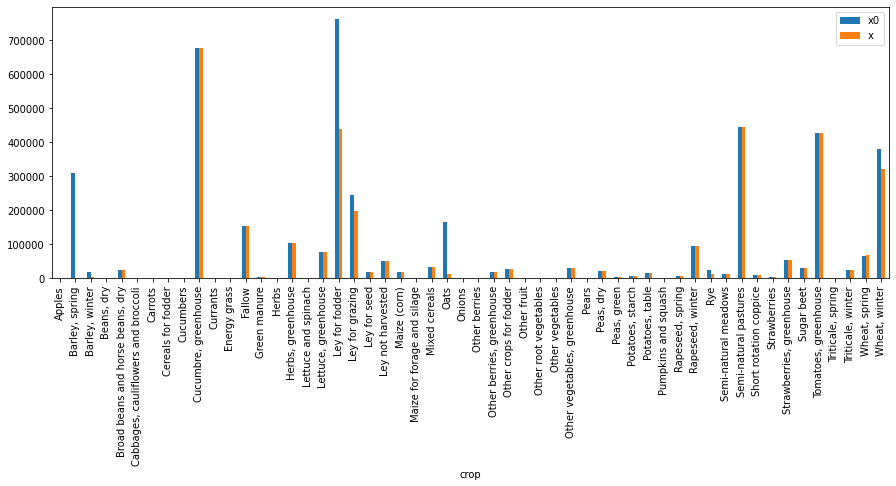

In [230]:
fig, ax = plt.subplots(figsize=(15,5))

pd.concat([
    geodist.x0['crp'].groupby('crop').sum().rename('x0'),
    out_crops.area.groupby('crop').sum().rename('x')
], axis=1).plot.bar(ax=ax)

plt.show()

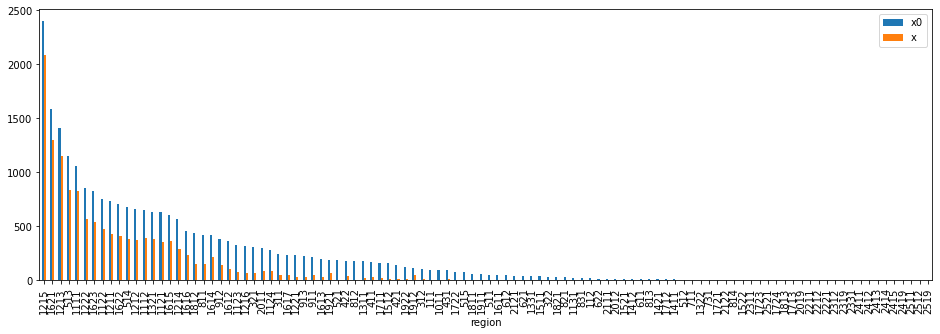

In [231]:
crp = 'Rye'

fig, ax = plt.subplots(figsize=(16,5))

pd.concat([
    geodist.x0['crp'].xs(crp, level='crop').groupby('region').sum().rename('x0'),
    out_crops.area.xs(crp, level='crop').groupby('region').sum().rename('x')
], axis=1).sort_values('x0', ascending=False).plot.bar(ax=ax)

plt.show()

In [232]:
pd.concat([
    x0_crp.groupby('crop').sum().rename('x0'),
    out_crops.area.groupby('crop').sum().rename('x')
], axis=1).plot.bar(ax=ax)

plt.show()

In [233]:
idx = pd.IndexSlice

print(
    pd.concat([
        out_animals.heads
        .groupby(['species','breed','prod_system','animal'], axis=1).sum()
        .sum().loc[idx[:,:,:,['cows','sows']]].droplevel('animal')
        .rename('x')
        ,
        x0_ani
        .groupby(['species','breed','prod_system']).sum()
        .rename('x0')
    ], axis=1)
    .apply(
        lambda x:
        pd.Series(
            [x['x'].round(1),x['x0'].round(1),((x['x']-x['x0'])/x['x0']*100).round(1)],
            index = ['x','x0','% dif']
        ),
        axis=1
    )
)

print(
    pd.concat([
        out_crops.area.groupby('crop').sum().rename('x'),
        x0_crp.groupby('crop').sum().rename('x0')
    ], axis=1)
    .apply(
        lambda x:
        pd.Series(
            [x['x'].round(1),x['x0'].round(1),((x['x']-x['x0'])/x['x0']*100).round(1)],
            index = ['x','x0','% dif']
        ),
        axis=1
    )
)

                                   x        x0  % dif
species breed prod_system                            
cattle  beef  conventional  220745.5  128080.1   72.3
              organic        67776.0   72274.4   -6.2
        dairy conventional  233433.0  263227.4  -11.3
              organic        52369.2   54920.6   -4.6
pigs    none  conventional  101409.5  132262.5  -23.3
              organic         3426.8    3325.0    3.1
                                            x        x0  % dif
crop                                                          
Apples                                 1552.0    1552.0    0.0
Barley, spring                            0.0  309454.0 -100.0
Barley, winter                         3464.3   18623.4  -81.4
Beans, dry                              703.3     703.3    0.0
Broad beans and horse beans, dry      25705.4   25705.0    0.0
Cabbages, cauliflowers and broccoli    1468.5    1468.5    0.0
Carrots                                1760.5    1760.5    0.0
C

C:\Users\jnka0003\AppData\Local\Temp\ipykernel_16392\3424063546.py:32: RuntimeWarning: divide by zero encountered in double_scalars
  [x['x'].round(1),x['x0'].round(1),((x['x']-x['x0'])/x['x0']*100).round(1)],
C:\Users\jnka0003\AppData\Local\Temp\ipykernel_16392\3424063546.py:32: RuntimeWarning: divide by zero encountered in double_scalars
  [x['x'].round(1),x['x0'].round(1),((x['x']-x['x0'])/x['x0']*100).round(1)],


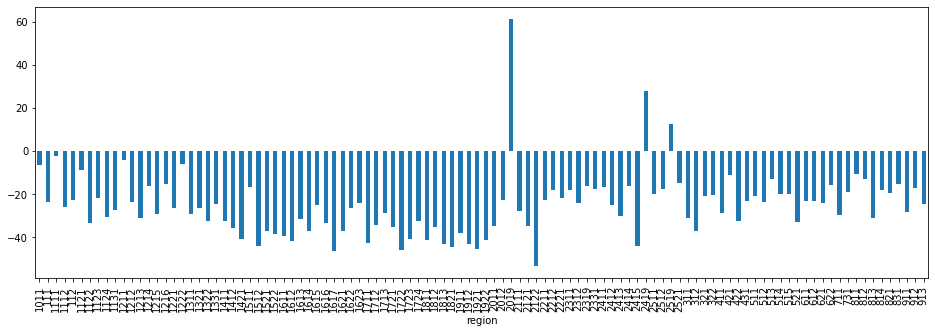

In [255]:
fig, ax = plt.subplots(figsize=(16,5))
(pd.concat([
    out_crops.area.groupby('region').sum().rename('x'),
    x0_crp.groupby('region').sum().rename('x0')
], axis=1)
.apply(
    lambda x:
    pd.Series(
        [x['x'].round(1),x['x0'].round(1),((x['x']-x['x0'])/x['x0']*100).round(1)],
        index = ['x','x0','% dif']
    ),
    axis=1
))['% dif'].plot.bar()
plt.show()

C:\Users\jnka0003\AppData\Local\Temp\ipykernel_16392\358283571.py:9: RuntimeWarning: divide by zero encountered in double_scalars
  [x['x'].round(1),x['x0'].round(1),((x['x']-x['x0'])/x['x0']*100).round(1)],
C:\Users\jnka0003\AppData\Local\Temp\ipykernel_16392\358283571.py:9: RuntimeWarning: divide by zero encountered in double_scalars
  [x['x'].round(1),x['x0'].round(1),((x['x']-x['x0'])/x['x0']*100).round(1)],


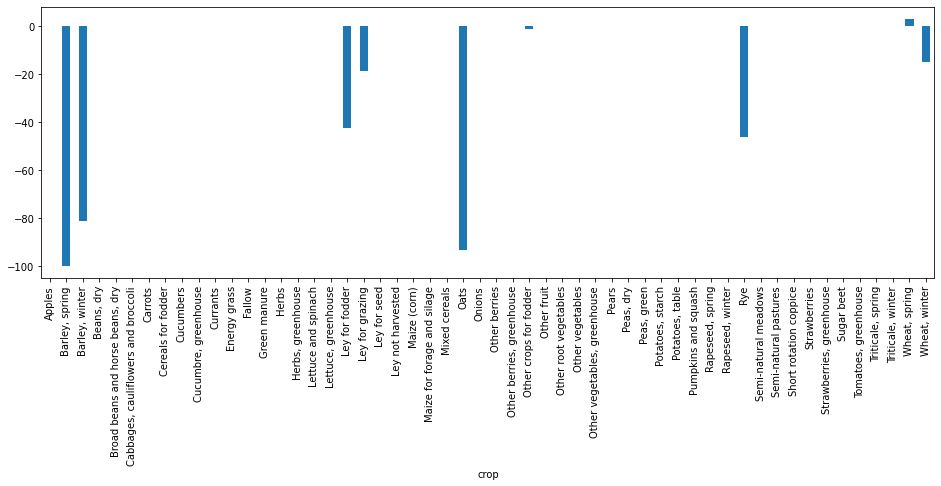

In [257]:
fig, ax = plt.subplots(figsize=(16,5))
(pd.concat([
    out_crops.area.groupby('crop').sum().rename('x'),
    x0_crp.groupby('crop').sum().rename('x0')
], axis=1)
.apply(
    lambda x:
    pd.Series(
        [x['x'].round(1),x['x0'].round(1),((x['x']-x['x0'])/x['x0']*100).round(1)],
        index = ['x','x0','% dif']
    ),
    axis=1
))['% dif'].plot.bar()
plt.show()

In [256]:
geodist.x0s['crp'][geodist.x0s['crp']>0].loc[(slice(None),slice(None),'2019')]

crop                   prod_system 
Fallow                 conventional     0.179220
                       organic          0.300698
Ley for fodder         conventional     2.379758
                       organic          2.861186
Ley for grazing        conventional     2.587314
                       organic          3.017873
Ley not harvested      conventional     3.969011
                       organic         10.782440
Semi-natural meadows   conventional     4.037881
                       organic          6.824536
Semi-natural pastures  conventional    37.292977
                       organic         69.083780
Name: area, dtype: float64

<AxesSubplot:xlabel='species,breed,prod_system'>

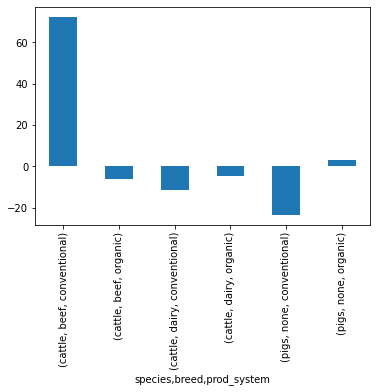

In [260]:
(pd.concat([
    out_animals.heads
    .groupby(['species','breed','prod_system','animal'], axis=1).sum()
    .sum().loc[idx[:,:,:,['cows','sows']]].droplevel('animal')
    .rename('x')
    ,
    x0_ani
    .groupby(['species','breed','prod_system']).sum()
    .rename('x0')
], axis=1)
.apply(
    lambda x:
    pd.Series(
        [x['x'].round(1),x['x0'].round(1),((x['x']-x['x0'])/x['x0']*100).round(1)],
        index = ['x','x0','% dif']
    ),
    axis=1
))['% dif'].plot.bar()